# MMAC Task 1 - Myopic Maculopathy Classification: **Baseline**


As per Category 2, AI (Claude was used as a proofreader)

## 1. Imports and setup


In [ ]:
# Standard library
import json
import math
import os
import random
import time
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch + vision
import torch
import torch.nn as nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    LambdaLR,
    ReduceLROnPlateau,
    SequentialLR,
)
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from tqdm.auto import tqdm

# scikit-learn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# Styling
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")


## 2. Project constants and device selection


In [ ]:
# Paths relative to project root
PROJECT_ROOT: Path = Path.cwd()
TRAIN_DIR: Path = PROJECT_ROOT / "data" / "Training" / "Training_Images"
TRAIN_CSV: Path = PROJECT_ROOT / "data" / "Training" / "Training_LabelsDemographic.csv"
TEST_DIR: Path = PROJECT_ROOT / "data" / "Testing" / "Testing_Images"
TEST_CSV: Path = PROJECT_ROOT / "data" / "Testing" / "Testing_LabelDemographic.csv"
CHECKPOINT_DIR: Path = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR: Path = PROJECT_ROOT / "outputs"

for path in [CHECKPOINT_DIR / "baseline", OUTPUT_DIR / "baseline"]:
    path.mkdir(parents=True, exist_ok=True)

# META-PM grades (5 classes)
NUM_CLASSES: int = 5
CLASS_NAMES: Tuple[str, ...] = (
    "0: No macular lesions",
    "1: Tessellated fundus",
    "2: Diffuse atrophy",
    "3: Patchy atrophy",
    "4: Macular atrophy",
)
LABEL_COL: str = "myopic_maculopathy_grade"
IMAGE_COL: str = "image"

# Device selection
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# ImageNet mean/std
IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device      : {get_device()}")


## 3. Configuration - `BaselineConfig`


In [ ]:
@dataclass
class BaselineConfig:
    """All the knobs for one training run.
    """

    # Reproducibility
    seed: int = 42

    # Data
    image_size: int = 224            # ResNet-50 / ImageNet canonical input
    val_split: float = 0.15          # fraction of training set held out for validation
    num_workers: int = 4             # DataLoader workers
    batch_size: int = 16             # safe for MPS with ResNet-50 @ 224
    train_fraction: float = 1.0      # <1.0 → stratified subsample of training split
    augmentation: bool = True        # False → use eval transform for training too
    return_metadata: bool = False    # Return the gender, data center, etc as well
    balanced_sampler: bool = False   # Balanced sampling from the age, gender and data center categories

    # Model
    backbone: str = "resnet50"       # torchvision backbone
    pretrained: bool = True
    dropout: float = 0.3             # applied in the new classification head
    add_max_pooling: bool = False    # adds max pooling as it helps with t
    num_meta_features: int = 0       # the number of features from the metadata to use

    # Training
    epochs: int = 30
    head_lr: float = 1e-3            # newly-initialised classifier head
    backbone_lr: float = 1e-4        # finetuned pretrained backbone
    weight_decay: float = 1e-4
    scheduler: str = "cosine"        # "cosine" or "plateau"
    warmup_epochs: int = 1           # linear warm-up before the main schedule
    label_smoothing: float = 0.0     # keep baseline vanilla; imbalance task may raise it
    weighted_ce: bool = False        # whether to use weighted cross entropy loss or not 
    use_bias_loss: bool = False      # whether to use the loss handling the bias

    # Regularisation / stability
    grad_clip: float = 1.0           # global gradient-norm clip
    use_amp: bool = True             # mixed precision (auto-disabled on MPS)

    early_stop_patience: int = 7
    primary_metric: str = "quadratic_kappa"  # MMAC-style ordinal metric

    # Checkpointing / logging
    checkpoint_dir: Path = field(default_factory=lambda: CHECKPOINT_DIR / "baseline")
    output_dir: Path = field(default_factory=lambda: OUTPUT_DIR / "baseline")
    experiment_name: str = "baseline_resnet50"

    def __post_init__(self) -> None:
        self.checkpoint_dir = Path(self.checkpoint_dir)
        self.output_dir = Path(self.output_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)


## 4. Data pipeline


In [ ]:
from torch.utils.data import WeightedRandomSampler

def get_balanced_sampler(df):
    # Use < 50 to tackled the age bias
    temp_age = df['age'].fillna(-1)
    age_bin = (df['age'] < 50).astype(int)

    temp_sex = df['sex'].fillna("Unknown")
    temp_center = df['data_center'].fillna("Unknown")
    
    super_groups = (
        temp_sex.astype(str) + "_" + 
        temp_center.astype(str) + "_" + 
        age_bin.astype(str)
    )
    
    group_counts = super_groups.value_counts()
    group_weights = 1.0 / group_counts
    
    sample_weights = super_groups.map(group_weights).values
    sample_weights = np.nan_to_num(sample_weights, nan=0.0)
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(), 
        num_samples=len(sample_weights), 
        replacement=True
    )
    return sampler

In [29]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, Optional, Tuple
from dataclasses import dataclass
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)

def build_train_transform(image_size: int = 224) -> transforms.Compose:
    """Train-time augmentation pipeline.

    No vertical flips: they break fundus topology. Horizontal flip is OK
    because left/right eyes are approximately mirror-symmetric. Rotation
    capped at ±10° to keep macular orientation intact.
    """
    return transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.15)),
            transforms.RandomResizedCrop(
                image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )

def build_eval_transform(image_size: int = 224) -> transforms.Compose:
    """Deterministic val/test transform — no random ops."""
    return transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.15)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )

@dataclass
class MMACClassificationDataset(Dataset):
    """Yields (image, label) pairs, or (image, label, metadata_dict).

    ``frame`` is a slice of the labels CSV. ``transform=None`` returns the
    raw PIL image (handy for EDA plots). ``return_metadata=True`` switches
    on the demographic dict used by the multi-task / bias extensions.
    """

    frame: pd.DataFrame
    image_dir: Path
    transform: Optional[transforms.Compose] = None
    return_metadata: bool = False

    def __post_init__(self) -> None:
        self.frame = self.frame.reset_index(drop=True)
        self.image_dir = Path(self.image_dir)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        img_path = self.image_dir / row[IMAGE_COL]
        # force 3-channel RGB
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = int(row[LABEL_COL])

        if not self.return_metadata:
            return image, label

        meta = _encode_metadata(row)
        return image, label, meta


        # meta = _encode_metadata(row)
        # return image, label, meta

def _encode_metadata(row: pd.Series) -> Dict[str, torch.Tensor]:
    """Pack the demographic columns into small tensors.

    Sex maps to {male: 0, female: 1, missing: -1}. Numeric fields come with
    a companion missing-mask tensor; how to impute them is left to the
    consuming extension model.
    """
    sex_map = {"male": 0, "female": 1}
    raw_sex = row.get("sex")
    sex = sex_map.get(raw_sex, -1) if isinstance(raw_sex, str) else -1

    def _num(v: object) -> Tuple[float, float]:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return 0.0, 1.0  # value, missing-mask
        return float(v), 0.0

    age_v, age_m = _num(row.get("age"))
    h_v, h_m = _num(row.get("height"))
    w_v, w_m = _num(row.get("weight"))

    return {
        "sex": torch.tensor(sex, dtype=torch.long),
        "age": torch.tensor(age_v, dtype=torch.float32),
        "age_missing": torch.tensor(age_m, dtype=torch.float32),
        "height": torch.tensor(h_v, dtype=torch.float32),
        "height_missing": torch.tensor(h_m, dtype=torch.float32),
        "weight": torch.tensor(w_v, dtype=torch.float32),
        "weight_missing": torch.tensor(w_m, dtype=torch.float32),
        "data_center": torch.tensor(int(row.get("data_center", 0)), dtype=torch.long),
    }

def load_label_frame(csv_path: Path, image_dir: Path) -> pd.DataFrame:
    """Read the labels CSV and drop rows whose image file isn't on disk."""
    frame = pd.read_csv(csv_path)
    exists = frame[IMAGE_COL].apply(lambda n: (Path(image_dir) / n).is_file())
    missing = (~exists).sum()
    if missing:
        print(f"[data] Dropping {missing} rows with missing image files in {image_dir}")
        frame = frame[exists].reset_index(drop=True)
    return frame

def stratified_split(
    frame: pd.DataFrame,
    val_fraction: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Stratified train/val split. Grades 3/4 are <10% of train, so a
    plain random split can leave them missing from val."""
    train_idx, val_idx = train_test_split(
        np.arange(len(frame)),
        test_size=val_fraction,
        random_state=seed,
        shuffle=True,
        stratify=frame[LABEL_COL].values,
    )
    train_frame = frame.iloc[train_idx].reset_index(drop=True)
    val_frame = frame.iloc[val_idx].reset_index(drop=True)
    return train_frame, val_frame

def stratified_subsample(
    frame: pd.DataFrame,
    fraction: float,
    seed: int,
) -> pd.DataFrame:
    """Keep ~``fraction`` of the rows, stratified by label.

    Used for the learning-curve ablation (30/60/100%). Always run this
    *after* the train/val split so val + test stay identical across every
    point on the curve.
    """
    if fraction >= 1.0:
        return frame.reset_index(drop=True)
    if fraction <= 0.0:
        raise ValueError(f"train_fraction must be > 0, got {fraction}")
    keep_idx, _ = train_test_split(
        np.arange(len(frame)),
        train_size=fraction,
        random_state=seed,
        shuffle=True,
        stratify=frame[LABEL_COL].values,
    )
    return frame.iloc[keep_idx].reset_index(drop=True)

def build_dataloaders(
    config: BaselineConfig,
) -> Dict[str, DataLoader]:
    """Read CSVs, split, build datasets, return train/val/test DataLoaders.

    The raw Datasets are also stashed under ``train_ds``/``val_ds``/
    ``test_ds`` so callers can poke at the frames (EDA, class weights,
    ...) without re-reading the CSV.
    """
    train_frame = load_label_frame(TRAIN_CSV, TRAIN_DIR)
    test_frame = load_label_frame(TEST_CSV, TEST_DIR)

    train_frame, val_frame = stratified_split(
        train_frame, val_fraction=config.val_split, seed=config.seed
    )

    if getattr(config, "train_fraction", 1.0) < 1.0:
        before = len(train_frame)
        train_frame = stratified_subsample(
            train_frame, config.train_fraction, config.seed
        )
        print(
            f"[data] train_fraction={config.train_fraction}: "
            f"reduced training set from {before} to {len(train_frame)} images"
        )

    eval_tfm = build_eval_transform(config.image_size)
    train_tfm = (
        build_train_transform(config.image_size)
        if getattr(config, "augmentation", True)
        else eval_tfm
    )
    if not getattr(config, "augmentation", True):
        print("[data] augmentation=False: training uses the eval transform")

    train_ds = MMACClassificationDataset(
        train_frame, TRAIN_DIR, transform=train_tfm, return_metadata=config.return_metadata
    )
    val_ds = MMACClassificationDataset(
        val_frame, TRAIN_DIR, transform=eval_tfm, return_metadata=config.return_metadata
    )
    test_ds = MMACClassificationDataset(
        test_frame, TEST_DIR, transform=eval_tfm, return_metadata=config.return_metadata
    )

    common_kwargs = dict(
        batch_size=config.batch_size,
        num_workers=config.num_workers,
        pin_memory=True,
        persistent_workers=config.num_workers > 0,
    )

    loaders = {
        "val": DataLoader(val_ds, shuffle=False, drop_last=False, **common_kwargs),
        "test": DataLoader(test_ds, shuffle=False, drop_last=False, **common_kwargs),
    }

    if config.balanced_sampler:
        train_sampler = get_balanced_sampler(train_frame)
        loaders["train"] = DataLoader(train_ds, shuffle=False, drop_last=True, sampler=train_sampler, **common_kwargs)
    else:
        loaders["train"] = DataLoader(train_ds, shuffle=True, drop_last=True, **common_kwargs)

    loaders["train_ds"] = train_ds
    loaders["val_ds"] = val_ds
    loaders["test_ds"] = test_ds
    return loaders

def class_counts(frame: pd.DataFrame, num_classes: int = NUM_CLASSES) -> np.ndarray:
    """Per-class row counts as an int array of length ``num_classes``."""
    counts = np.zeros(num_classes, dtype=np.int64)
    for k, v in frame[LABEL_COL].value_counts().items():
        counts[int(k)] = int(v)
    return counts

def inverse_frequency_weights(
    frame: pd.DataFrame, num_classes: int = NUM_CLASSES
) -> torch.Tensor:
    """1/frequency class weights, rescaled to sum to ``num_classes``.

    Baseline ignores this; exposed here so the imbalance extension has
    a single place to import from.
    """
    counts = class_counts(frame, num_classes).astype(np.float64)
    counts = np.where(counts == 0, 1, counts)
    weights = counts.sum() / counts
    weights = weights * (num_classes / weights.sum())
    return torch.tensor(weights, dtype=torch.float32)

def calculate_iptw_ratios(df: pd.DataFrame):
    """
    Calculates weights based for the harder groups
    Formula: Weight = 1 / P(Group)
    """
    total_n = len(df)
    
    # Probability of being in the 'Underperforming' groups
    p_young = len(df[df['age'] < 50]) / total_n
    p_old = len(df[df['age'] >= 70]) / total_n
    p_center1 = len(df[df['data_center'] == 1]) / total_n
    p_center2 = len(df[df['data_center'] == 2]) / total_n
    p_female = len(df[df['sex'] == 1]) / total_n
    p_male = len(df[df['sex'] == 0]) / total_n
    
    # Calculate inverse weights
    weights = {
        'young': 1.0 / max(p_young, 0.001),
        'old': 1.0 / max(p_old, 0.001),
        'center1': 1.0 / max(p_center1, 0.001),
        'center2': 1.0 / max(p_center2, 0.001),
        'female': 1.0 / max(p_female, 0.001),
        'male': 1.0 / max(p_male, 0.001),
        'baseline': 1.0  # Weight for majority/easy groups
    }
    
    # Normalize weights so the baseline is 1.0 (easier to monitor loss)
    norm_factor = weights['baseline']
    return {k: v / norm_factor for k, v in weights.items()}


def generic_fairness_loss(logits, y, meta, iptw_weights, parity_lambda = 0.5):
    per_sample_criterion = nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)
    raw_loss = per_sample_criterion(logits, y)
    
    is_young = (meta['age'] < 50)
    is_old = (meta['age'] >= 70)
    is_female = (meta['sex'] == 1)
    is_male = (meta['sex'] == 0)
    is_c1 = (meta['data_center'] == 1)
    is_c2 = (meta['data_center'] == 2)
    
    # Additive IPTW Weighting
    weights = torch.ones_like(raw_loss)
    if is_c2.any(): weights += is_c2.float() * (iptw_weights['center2'] - 1.0)
    if is_female.any(): weights += is_female.float() * (iptw_weights['female'] - 1.0)
    if is_old.any(): weights += is_old.float() * (iptw_weights['old'] - 1.0)
    
    weights = weights / weights.mean()

    # 4. Parity Penalties (Consistency) 
    
    age_gap = torch.abs(raw_loss[is_young].mean() - raw_loss[~is_young].mean()) if is_young.any() else 0
    sex_gap = torch.abs(raw_loss[is_male].mean() - raw_loss[is_female].mean()) if (is_male.any() and is_female.any()) else 0
    center_gap = torch.abs(raw_loss[is_c1].mean() - raw_loss[is_c2].mean()) if (is_c1.any() and is_c2.any()) else 0

    weighted_loss = (raw_loss * weights).mean()
    total_penalty = age_gap + sex_gap + center_gap
    
    return weighted_loss + (parity_lambda * total_penalty)

## 5. Model - `MMACResNet50`


In [ ]:
import torch
import torch.nn as nn
from typing import List, Tuple
from torchvision import models
from torchvision.models import ResNet50_Weights

class MMACResNet50(nn.Module):
    """ResNet-50 backbone + a small MLP head (2048→512→5).

    Linear-BN-ReLU-Dropout-Linear. The extra hidden layer gives the
    network a little room to remap ImageNet features onto the 5 grades
    without blowing the parameter budget. Dropout rate is set by
    ``BaselineConfig.dropout``.
    """

    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        pretrained: bool = True,
        dropout: float = 0.3,
        add_max_pooling = False,
        num_meta_features: int = 0, # Age, Sex, Center
    ) -> None:
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        self.add_max_pooling = add_max_pooling
        self.num_meta_features = num_meta_features
        in_features = self.backbone.fc.in_features

        if add_max_pooling:
            in_features *= 2
        if num_meta_features > 0:
            in_features += 64

        self.backbone.fc = nn.Identity()  # strip the original 1000-class head

        if num_meta_features > 0:
            self.meta_proj = nn.Sequential(
                nn.Linear(num_meta_features, 64),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.Dropout(0.8) # High dropout prevents the model from over-relying on age
            )

        self.head = nn.Sequential(
            nn.Linear(in_features, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )
        new_layers = list(self.head.modules())
        if num_meta_features > 0:
            new_layers = list(self.meta_proj.modules()) + list(self.head.modules())
        # init new layers
        for m in new_layers:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, meta: torch.Tensor = None
    ) -> torch.Tensor:
        if not self.add_max_pooling:
            features = self.backbone(x)
        else:
            # Get features from backbone before the Identity() layer
            # ResNet50 features are [Batch, 2048, 7, 7] before pooling
            x = self.backbone.conv1(x)
            x = self.backbone.bn1(x)
            x = self.backbone.relu(x)
            x = self.backbone.maxpool(x)
            x = self.backbone.layer1(x)
            x = self.backbone.layer2(x)
            x = self.backbone.layer3(x)
            x = self.backbone.layer4(x)

            avg_pool = torch.mean(x, dim=[2, 3])
            max_pool = torch.amax(x, dim=(2, 3))
            
            # features now 4096 instead of 2048
            features = torch.cat([avg_pool, max_pool], dim=1)
        
        if self.num_meta_features > 0:
            projected_meta = self.meta_proj(meta)
            combined_features = torch.cat([features, projected_meta], dim=1)
            return self.head(combined_features)
        return self.head(features)

    def parameter_groups(
        self, backbone_lr: float, head_lr: float, weight_decay: float
    ) -> List[dict]:
        """Two param groups so the optimiser can give the fresh head a
        higher LR than the pretrained backbone."""
        new_params = list(self.head.parameters())
        if self.num_meta_features > 0:
            new_params = list(self.meta_proj.parameters()) + list(self.head.parameters())
        return [
            {
                "params": list(self.backbone.parameters()),
                "lr": backbone_lr,
                "weight_decay": weight_decay,
                "name": "backbone",
            },
            {
                "params": new_params,
                "lr": head_lr,
                "weight_decay": weight_decay,
                "name": "head",
            },
        ]

def build_model(config: BaselineConfig) -> MMACResNet50:
    """Build the model from config. Keeps architecture code out of the notebook."""
    if config.backbone != "resnet50":
        raise ValueError(
            f"Baseline only supports ResNet-50; got {config.backbone!r}. "
            "Extension models can override this."
        )
    return MMACResNet50(
        num_classes=NUM_CLASSES,
        pretrained=config.pretrained,
        dropout=config.dropout,
        add_max_pooling=config.add_max_pooling,
        num_meta_features=config.num_meta_features
    )

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """(trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


## 6. Metrics and bootstrap inference


In [ ]:
import numpy as np
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, f1_score, precision_recall_fscore_support, roc_auc_score,
)

_SCALAR_METRICS: Tuple[str, ...] = (
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "quadratic_kappa",
    "macro_auroc",
)

@dataclass
class MetricBundle:
    """One epoch's worth of metrics."""

    accuracy: float
    balanced_accuracy: float
    macro_f1: float
    weighted_f1: float
    quadratic_kappa: float
    macro_auroc: Optional[float]
    per_class_precision: List[float] = field(default_factory=list)
    per_class_recall: List[float] = field(default_factory=list)
    per_class_f1: List[float] = field(default_factory=list)
    per_class_support: List[int] = field(default_factory=list)
    confusion_matrix: List[List[int]] = field(default_factory=list)

    def to_dict(self) -> Dict[str, object]:
        """Flat dict for JSON logging."""
        return {
            "accuracy": self.accuracy,
            "balanced_accuracy": self.balanced_accuracy,
            "macro_f1": self.macro_f1,
            "weighted_f1": self.weighted_f1,
            "quadratic_kappa": self.quadratic_kappa,
            "macro_auroc": self.macro_auroc,
            "per_class_precision": self.per_class_precision,
            "per_class_recall": self.per_class_recall,
            "per_class_f1": self.per_class_f1,
            "per_class_support": self.per_class_support,
            "confusion_matrix": self.confusion_matrix,
        }

    def pretty(self) -> str:
        auroc = (
            f"{self.macro_auroc:.4f}"
            if self.macro_auroc is not None and np.isfinite(self.macro_auroc)
            else "  n/a"
        )
        return (
            f"acc={self.accuracy:.4f}  bal_acc={self.balanced_accuracy:.4f}  "
            f"macroF1={self.macro_f1:.4f}  kappa={self.quadratic_kappa:.4f}  "
            f"AUROC={auroc}"
        )

def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None,
    num_classes: int = NUM_CLASSES,
) -> MetricBundle:
    
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    labels = list(range(num_classes))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic")
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    auroc: Optional[float] = None
    if y_prob is not None:
        y_prob = np.asarray(y_prob)
        present = np.unique(y_true)
        if len(present) >= 2:
            try:
                auroc = roc_auc_score(y_true, y_prob, multi_class="ovr",
                                      average="macro", labels=labels)
                if auroc is not None and not np.isfinite(auroc):
                    auroc = roc_auc_score(y_true, y_prob[:, present],
                                          multi_class="ovr", average="macro",
                                          labels=present.tolist())
                    if auroc is not None and not np.isfinite(auroc):
                        auroc = None
            except ValueError:
                auroc = None

    return MetricBundle(
        accuracy=float(acc), balanced_accuracy=float(bal_acc),
        macro_f1=float(macro_f1), weighted_f1=float(weighted_f1),
        quadratic_kappa=float(kappa),
        macro_auroc=float(auroc) if auroc is not None else None,
        per_class_precision=[float(p) for p in precision],
        per_class_recall=[float(r) for r in recall],
        per_class_f1=[float(f) for f in f1_per_class],
        per_class_support=[int(s) for s in support],
        confusion_matrix=[[int(x) for x in row] for row in cm],
    )

def _stratified_bootstrap_index(y_true: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """One stratified resample (with replacement) for bootstrap inference."""
    idx_out = np.empty_like(y_true, dtype=np.int64)
    pos = 0
    for c in np.unique(y_true):
        class_idx = np.flatnonzero(y_true == c)
        draws = rng.integers(0, len(class_idx), size=len(class_idx))
        idx_out[pos : pos + len(class_idx)] = class_idx[draws]
        pos += len(class_idx)
    return idx_out

def bootstrap_metrics(
    y_true: np.ndarray, y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None, *,
    num_classes: int = NUM_CLASSES, n_resamples: int = 1000,
    ci_level: float = 0.95, seed: int = 42,
) -> Dict[str, Dict[str, float]]:
    """Percentile-bootstrap CIs for every scalar metric."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if y_prob is not None:
        y_prob = np.asarray(y_prob)

    point = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    point_dict = point.to_dict()
    samples: Dict[str, List[float]] = {m: [] for m in _SCALAR_METRICS}
    rng = np.random.default_rng(seed)

    for _ in range(n_resamples):
        idx = _stratified_bootstrap_index(y_true, rng)
        b = compute_metrics(y_true[idx], y_pred[idx],
                            y_prob[idx] if y_prob is not None else None,
                            num_classes=num_classes)
        for m in _SCALAR_METRICS:
            v = getattr(b, m)
            if v is not None and np.isfinite(v):
                samples[m].append(float(v))

    alpha = (1.0 - ci_level) / 2.0
    results: Dict[str, Dict[str, float]] = {}
    for m in _SCALAR_METRICS:
        arr = np.asarray(samples[m], dtype=float)
        point_val = point_dict.get(m)
        point_val = float(point_val) if point_val is not None else float("nan")
        if arr.size == 0:
            results[m] = {"point": point_val, "ci_low": float("nan"),
                          "ci_high": float("nan"), "std": float("nan")}
            continue
        lo, hi = np.quantile(arr, [alpha, 1.0 - alpha])
        results[m] = {"point": point_val, "ci_low": float(lo),
                       "ci_high": float(hi),
                       "std": float(arr.std(ddof=1)) if arr.size > 1 else 0.0}
    return results

def format_ci(ci: Dict[str, float], digits: int = 4) -> str:
    """Format as ``0.7412 [0.6891, 0.7893]``."""
    p = ci.get("point", float("nan"))
    lo = ci.get("ci_low", float("nan"))
    hi = ci.get("ci_high", float("nan"))
    if not (np.isfinite(p) and np.isfinite(lo) and np.isfinite(hi)):
        return f"{p:.{digits}f}  [n/a]"
    return f"{p:.{digits}f}  [{lo:.{digits}f}, {hi:.{digits}f}]"

def paired_bootstrap_compare(
    y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray,
    y_prob_a: Optional[np.ndarray] = None,
    y_prob_b: Optional[np.ndarray] = None, *,
    num_classes: int = NUM_CLASSES, metric: str = "quadratic_kappa",
    n_resamples: int = 2000, ci_level: float = 0.95, seed: int = 42,
) -> Dict[str, float]:
    """Paired bootstrap comparison of two models on the same test set."""
    y_true = np.asarray(y_true).astype(int)
    y_pred_a = np.asarray(y_pred_a).astype(int)
    y_pred_b = np.asarray(y_pred_b).astype(int)
    if y_prob_a is not None: y_prob_a = np.asarray(y_prob_a)
    if y_prob_b is not None: y_prob_b = np.asarray(y_prob_b)

    def _scalar(y, p, q):
        bundle = compute_metrics(y, p, q, num_classes=num_classes)
        v = getattr(bundle, metric)
        return float(v) if v is not None and np.isfinite(v) else np.nan

    metric_a = _scalar(y_true, y_pred_a, y_prob_a)
    metric_b = _scalar(y_true, y_pred_b, y_prob_b)
    delta_point = metric_a - metric_b

    rng = np.random.default_rng(seed)
    deltas: List[float] = []
    for _ in range(n_resamples):
        idx = _stratified_bootstrap_index(y_true, rng)
        va = _scalar(y_true[idx], y_pred_a[idx],
                     y_prob_a[idx] if y_prob_a is not None else None)
        vb = _scalar(y_true[idx], y_pred_b[idx],
                     y_prob_b[idx] if y_prob_b is not None else None)
        if np.isfinite(va) and np.isfinite(vb):
            deltas.append(va - vb)

    arr = np.asarray(deltas, dtype=float)
    alpha_val = (1.0 - ci_level) / 2.0
    lo, hi = np.quantile(arr, [alpha_val, 1.0 - alpha_val]) if arr.size else (np.nan, np.nan)

    if arr.size == 0 or not np.isfinite(delta_point):
        p_value = float("nan")
    else:
        if delta_point >= 0:
            tail = float((arr <= 0).sum()) / arr.size
        else:
            tail = float((arr >= 0).sum()) / arr.size
        p_value = min(1.0, 2.0 * tail)

    return {"metric_a": metric_a, "metric_b": metric_b, "delta": delta_point,
            "ci_low": float(lo), "ci_high": float(hi), "p_value": p_value,
            "n_resamples": int(arr.size)}


## 7. Utilities


In [ ]:
import json
import os
import random
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed: int, deterministic: bool = False) -> None:
    """Seed python/numpy/torch RNGs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def enable_cuda_optimizations(use_tf32: bool = True) -> None:
    
    if not torch.cuda.is_available():
        return
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    if use_tf32:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

def unwrap_model(model: torch.nn.Module) -> torch.nn.Module:
    """Strip DataParallel if present, return the inner module otherwise."""
    if isinstance(model, torch.nn.DataParallel):
        return model.module
    return model

def save_checkpoint(
    path: Path, *, model: torch.nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[object] = None, epoch: int,
    metrics: Optional[Dict[str, Any]] = None,
    extra: Optional[Dict[str, Any]] = None,
) -> None:
    """Write a full training checkpoint to ``path``."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload: Dict[str, Any] = {
        "epoch": int(epoch),
        "model_state": unwrap_model(model).state_dict(),
        "metrics": metrics or {},
        "extra": extra or {},
    }
    if optimizer is not None:
        payload["optimizer_state"] = optimizer.state_dict()
    if scheduler is not None and hasattr(scheduler, "state_dict"):
        payload["scheduler_state"] = scheduler.state_dict()
    torch.save(payload, path)

def load_checkpoint(
    path: Path, *, model: Optional[torch.nn.Module] = None,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[object] = None,
    map_location: Optional[str] = "cpu",
) -> Dict[str, Any]:
    """Load a checkpoint, optionally restoring model/optimiser/scheduler state."""
    payload = torch.load(path, map_location=map_location)
    if model is not None and "model_state" in payload:
        unwrap_model(model).load_state_dict(payload["model_state"])
    if optimizer is not None and "optimizer_state" in payload:
        optimizer.load_state_dict(payload["optimizer_state"])
    if scheduler is not None and "scheduler_state" in payload:
        scheduler.load_state_dict(payload["scheduler_state"])
    return payload

@dataclass
class TrainingHistory:
    """Per-epoch scalar log."""

    train_loss: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    train_metrics: List[Dict[str, Any]] = field(default_factory=list)
    val_metrics: List[Dict[str, Any]] = field(default_factory=list)
    learning_rates: List[List[float]] = field(default_factory=list)

    def append(self, *, train_loss: float, val_loss: float,
               train_metrics: Dict[str, Any], val_metrics: Dict[str, Any],
               learning_rates: List[float]) -> None:
        self.train_loss.append(float(train_loss))
        self.val_loss.append(float(val_loss))
        self.train_metrics.append(train_metrics)
        self.val_metrics.append(val_metrics)
        self.learning_rates.append([float(lr) for lr in learning_rates])

    def save(self, path: Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open("w") as f:
            json.dump(self.__dict__, f, indent=2, default=_json_default)

def _json_default(obj: Any) -> Any:
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(f"Not serializable: {type(obj)}")

def plot_training_curves(history: "TrainingHistory", save_path: Optional[Path] = None):
    """Loss + primary-metric curves. Returns the figure."""
    epochs = np.arange(1, len(history.train_loss) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history.train_loss, marker="o", label="train")
    axes[0].plot(epochs, history.val_loss, marker="o", label="val")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross-entropy loss")
    axes[0].set_title("Training / validation loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    train_kappa = [m.get("quadratic_kappa", np.nan) for m in history.train_metrics]
    val_kappa = [m.get("quadratic_kappa", np.nan) for m in history.val_metrics]
    val_acc = [m.get("accuracy", np.nan) for m in history.val_metrics]
    val_bal = [m.get("balanced_accuracy", np.nan) for m in history.val_metrics]

    axes[1].plot(epochs, train_kappa, marker="o", label="train k")
    axes[1].plot(epochs, val_kappa, marker="o", label="val k")
    axes[1].plot(epochs, val_acc, marker="s", linestyle="--", label="val acc")
    axes[1].plot(epochs, val_bal, marker="^", linestyle="--", label="val bal acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("metric")
    axes[1].set_title("Validation metrics (primary: quadratic k)")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

def plot_confusion_matrix(
    cm: np.ndarray, class_names: List[str], normalize: bool = True,
    save_path: Optional[Path] = None, title: str = "Confusion matrix",
):
    """Seaborn heatmap, row-normalised by default so the diagonal reads as recall."""
    cm = np.asarray(cm, dtype=np.float64)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm, row_sums, where=row_sums > 0)
        fmt = ".2f"
    else:
        cm_display = cm
        fmt = ".0f"

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar=True, ax=ax)
    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title + (" (row-normalised)" if normalize else ""))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


## 8. Training engine


In [ ]:
import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import (
    CosineAnnealingLR, LambdaLR, ReduceLROnPlateau, SequentialLR,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def build_optimizer(model: nn.Module, config: BaselineConfig) -> Optimizer:
    """AdamW with a lower LR on the pretrained backbone than on the head.

    Unwraps DataParallel first so ``parameter_groups`` is called on the
    real module (DataParallel doesn't forward custom methods).
    """
    param_groups = unwrap_model(model).parameter_groups(
        backbone_lr=config.backbone_lr,
        head_lr=config.head_lr,
        weight_decay=config.weight_decay,
    )
    return AdamW(param_groups)

def build_scheduler(
    optimizer: Optimizer,
    config: BaselineConfig,
    steps_per_epoch: int,
):
    """Linear warmup → cosine (or plateau) schedule.

    Warmup happens in epoch units — at epoch ``k`` the LR is ``(k+1)/warmup``
    times the base LR, then the main schedule takes over.
    """
    base_scheduler = (
        CosineAnnealingLR(
            optimizer,
            T_max=max(1, config.epochs - config.warmup_epochs),
            eta_min=0.0,
        )
        if config.scheduler == "cosine"
        else ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7
        )
    )
    if config.warmup_epochs <= 0:
        return base_scheduler

    warmup = LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: float(epoch + 1) / max(1, config.warmup_epochs),
    )
    if isinstance(base_scheduler, ReduceLROnPlateau):
                return {"warmup": warmup, "main": base_scheduler}
    return SequentialLR(
        optimizer, schedulers=[warmup, base_scheduler], milestones=[config.warmup_epochs]
    )

def _build_amp_scaler(use_amp: bool, device: torch.device) -> Optional[torch.cuda.amp.GradScaler]:

    if use_amp and device.type == "cuda":
        return torch.amp.GradScaler('cuda')
    return None

def _autocast_context(use_amp: bool, device: torch.device):

    if use_amp and device.type == "cuda":
        return torch.amp.autocast('cuda')
    class _Null:
        def __enter__(self_inner): return None
        def __exit__(self_inner, *exc): return False
    return _Null()

def _move_batch(batch, device: torch.device):
    """Push a (x, y) or (x, y, meta_dict) batch to device."""
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        x, y = batch[0].to(device, non_blocking=True), batch[1].to(
            device, non_blocking=True
        )
        rest = list(batch[2:])
        rest = [
            {k: v.to(device, non_blocking=True) for k, v in r.items()}
            if isinstance(r, dict)
            else r.to(device, non_blocking=True)
            for r in rest
        ]
        return (x, y, *rest) if rest else (x, y)
    raise ValueError("Unexpected batch format")

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optimizer,
    criterion: nn.Module,
    use_bias_loss: bool,
    device: torch.device,
    *,
    grad_clip: float = 0.0,
    use_amp: bool = False,
    epoch: int = 0,
    total_epochs: int = 0,
) -> Tuple[float, MetricBundle]:

    model.train()
    scaler = _build_amp_scaler(use_amp, device)

    running_loss = 0.0
    seen = 0
    all_targets: List[np.ndarray] = []
    all_preds: List[np.ndarray] = []
    all_probs: List[np.ndarray] = []

    model_module = model.module if hasattr(model, 'module') else model
    use_meta = getattr(model_module, 'num_meta_features', 0) > 0

    pbar = tqdm(
        loader,
        desc=f"train {epoch + 1}/{total_epochs}",
        leave=False,
        dynamic_ncols=True,
    )
    for batch in pbar:
        x, y, *rest = _move_batch(batch, device)
        
        optimizer.zero_grad(set_to_none=True)
        with _autocast_context(use_amp, device):
            if use_meta and rest:
                m = rest[0]
                # Convert dict to a single [Batch, 3] tensor
                # Ensure the order is ALWAYS [age, sex, center]
                age_normalised = m['age'] / 100.0
                meta_tensor = torch.stack([age_normalised, m['sex'], m['data_center']], dim=1).float()
                logits = model(x, meta_tensor)
            else:
                # Fallback if no meta is present
                logits = model(x)
   
            loss = None
            if rest and use_bias_loss:
                m = rest[0]
                df_train = loader.dataset.frame
                iptw_weights = calculate_iptw_ratios(df_train)
                loss = generic_fairness_loss(logits, y, m, iptw_weights)
            else:
                loss = criterion(logits, y)

        if scaler is not None:
            scaler.scale(loss).backward()
            if grad_clip and grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip and grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        bs = x.size(0)
        running_loss += float(loss.detach()) * bs
        seen += bs

        with torch.no_grad():
            probs = torch.softmax(logits.detach(), dim=1).float().cpu().numpy()
            preds = probs.argmax(axis=1)
            all_targets.append(y.detach().cpu().numpy())
            all_preds.append(preds)
            all_probs.append(probs)

        pbar.set_postfix(loss=f"{running_loss / max(seen, 1):.4f}")

    y_true = np.concatenate(all_targets) if all_targets else np.array([], dtype=int)
    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=int)
    y_prob = np.concatenate(all_probs) if all_probs else None
    metrics = compute_metrics(y_true, y_pred, y_prob)
    return running_loss / max(seen, 1), metrics

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    *,
    desc: str = "eval",
) -> Tuple[float, MetricBundle, np.ndarray, np.ndarray, np.ndarray]:
 
    model.eval()
    running_loss = 0.0
    seen = 0
    all_targets: List[np.ndarray] = []
    all_preds: List[np.ndarray] = []
    all_probs: List[np.ndarray] = []
    all_sex, all_age, all_center = [], [], []

    model_module = model.module if hasattr(model, 'module') else model
    use_meta = getattr(model_module, 'num_meta_features', 0) > 0

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    for batch in pbar:
        x, y, *rest = _move_batch(batch, device)
        if use_meta and rest:
            m = rest[0]
            # Convert dict to a single [Batch, 3] tensor
            # Ensure the order is ALWAYS [age, sex, center]
            age_normalised = m['age'] / 100.0
            meta_tensor = torch.stack([age_normalised, m['sex'], m['data_center']], dim=1).float()
            logits = model(x, meta_tensor)
        else:
            # Fallback if no meta is present
            logits = model(x)
        
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1).float().cpu().numpy()
        preds = probs.argmax(axis=1)
        all_targets.append(y.cpu().numpy())
        all_preds.append(preds)
        all_probs.append(probs)

        if rest and isinstance(rest[0], dict):
            m = rest[0]
            all_sex.append(m['sex'].cpu().numpy())
            all_age.append(m['age'].cpu().numpy())
            all_center.append(m['data_center'].cpu().numpy())

        bs = x.size(0)
        running_loss += float(loss) * bs
        seen += bs
        pbar.set_postfix(loss=f"{running_loss / max(seen, 1):.4f}")

    y_true = np.concatenate(all_targets) if all_targets else np.array([], dtype=int)
    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=int)
    y_prob = np.concatenate(all_probs) if all_probs else np.empty((0, 0))
    bundle = compute_metrics(y_true, y_pred, y_prob)

    meta_out = None
    if all_sex:
        meta_out = {
            'sex': np.concatenate(all_sex),
            'age': np.concatenate(all_age),
            'data_center': np.concatenate(all_center)
        }

    return running_loss / max(seen, 1), bundle, y_true, y_pred, y_prob, meta_out

@dataclass
class TrainResult:
    history: TrainingHistory
    best_epoch: int
    best_metric: float
    best_ckpt_path: Path
    last_ckpt_path: Path
    primary_metric: str

def load_trained_result(config: BaselineConfig) -> TrainResult:

    import json

    best_ckpt = config.checkpoint_dir / f"{config.experiment_name}_best.pt"
    last_ckpt = config.checkpoint_dir / f"{config.experiment_name}_last.pt"
    history_path = config.output_dir / f"{config.experiment_name}_history.json"

    if not best_ckpt.is_file():
        raise FileNotFoundError(
            f"Best checkpoint not found at {best_ckpt}. Train the baseline "
            "locally or copy the artefacts from the VPS before calling "
            "load_trained_result()."
        )
    if not history_path.is_file():
        raise FileNotFoundError(
            f"Training history not found at {history_path}."
        )

    with history_path.open() as f:
        raw = json.load(f)

    history = TrainingHistory(
        train_loss=list(raw.get("train_loss", [])),
        val_loss=list(raw.get("val_loss", [])),
        train_metrics=list(raw.get("train_metrics", [])),
        val_metrics=list(raw.get("val_metrics", [])),
        learning_rates=list(raw.get("learning_rates", [])),
    )

    val_metric_series = [
        m.get(config.primary_metric, -math.inf) for m in history.val_metrics
    ]
    if val_metric_series:
        best_epoch = int(max(range(len(val_metric_series)), key=val_metric_series.__getitem__))
        best_metric = float(val_metric_series[best_epoch])
    else:
        best_epoch = -1
        best_metric = float("nan")

    return TrainResult(
        history=history,
        best_epoch=best_epoch,
        best_metric=best_metric,
        best_ckpt_path=best_ckpt,
        last_ckpt_path=last_ckpt,
        primary_metric=config.primary_metric,
    )

def train(
    model: nn.Module,
    loaders: Dict[str, DataLoader],
    config: BaselineConfig,
    device: torch.device,
    *,
    criterion: Optional[nn.Module] = None,
) -> TrainResult:
    """End-to-end training loop with checkpointing + early stopping.

    Watches ``config.primary_metric`` on val and stops after
    ``config.early_stop_patience`` epochs without improvement. Best
    (by that metric) and last checkpoints are always written.
    """
    model.to(device)

    # multi-GPU
    if device.type == "cuda" and torch.cuda.device_count() > 1:
        gpu_ids = list(range(torch.cuda.device_count()))
        print(
            f"[train] Using nn.DataParallel across {len(gpu_ids)} GPUs: {gpu_ids}"
        )
        model = nn.DataParallel(model, device_ids=gpu_ids)

    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
        if config.weighted_ce:
            class_weights = inverse_frequency_weights(loaders["train_ds"].frame)
            class_weights = class_weights.to(device)
            criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing, weight=class_weights)
        

    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, steps_per_epoch=len(loaders["train"]))

    history = TrainingHistory()
    best_metric = -math.inf
    best_epoch = -1
    patience_left = config.early_stop_patience

    best_ckpt = config.checkpoint_dir / f"{config.experiment_name}_best.pt"
    last_ckpt = config.checkpoint_dir / f"{config.experiment_name}_last.pt"

    use_amp = config.use_amp and device.type == "cuda"

    print(
        f"[train] device={device.type}  epochs={config.epochs}  "
        f"batch_size={config.batch_size}  primary_metric={config.primary_metric}"
    )

    for epoch in range(config.epochs):
        t0 = time.time()

        if isinstance(scheduler, dict):
            active = scheduler["warmup"] if epoch < config.warmup_epochs else scheduler["main"]
        else:
            active = scheduler

        train_loss, train_metrics = train_one_epoch(
            model,
            loaders["train"],
            optimizer,
            criterion,
            config.use_bias_loss,
            device,
            grad_clip=config.grad_clip,
            use_amp=use_amp,
            epoch=epoch,
            total_epochs=config.epochs,
        )
        val_loss, val_metrics, *_ = evaluate(
            model,
            loaders["val"],
            criterion,
            device,
            desc=f"val   {epoch + 1}/{config.epochs}",
        )

        if isinstance(active, ReduceLROnPlateau):
            active.step(getattr(val_metrics, config.primary_metric))
        else:
            active.step()

        lrs = [pg["lr"] for pg in optimizer.param_groups]
        history.append(
            train_loss=train_loss,
            val_loss=val_loss,
            train_metrics=train_metrics.to_dict(),
            val_metrics=val_metrics.to_dict(),
            learning_rates=lrs,
        )

        current = getattr(val_metrics, config.primary_metric) or -math.inf
        improved = current > best_metric
        dt = time.time() - t0
        lr_str = ", ".join(f"{lr:.2e}" for lr in lrs)
        marker = "*" if improved else " "
        print(
            f"[epoch {epoch + 1:02d}/{config.epochs}] {marker} "
            f"train loss={train_loss:.4f} {train_metrics.pretty()} | "
            f"val loss={val_loss:.4f} {val_metrics.pretty()} | "
            f"lr=[{lr_str}] | {dt:.1f}s"
        )

        save_checkpoint(
            last_ckpt,
            model=model,
            optimizer=optimizer,
            scheduler=active if not isinstance(active, dict) else None,
            epoch=epoch,
            metrics=val_metrics.to_dict(),
            extra={"config": _config_to_dict(config)},
        )

        # Update best-only checkpoint.
        if improved:
            best_metric = current
            best_epoch = epoch
            patience_left = config.early_stop_patience
            save_checkpoint(
                best_ckpt,
                model=model,
                optimizer=optimizer,
                scheduler=active if not isinstance(active, dict) else None,
                epoch=epoch,
                metrics=val_metrics.to_dict(),
                extra={"config": _config_to_dict(config)},
            )
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(
                    f"[train] Early stopping at epoch {epoch + 1}: "
                    f"no improvement on {config.primary_metric} for "
                    f"{config.early_stop_patience} epochs."
                )
                break

        history.save(config.output_dir / f"{config.experiment_name}_history.json")

    return TrainResult(
        history=history,
        best_epoch=best_epoch,
        best_metric=best_metric,
        best_ckpt_path=best_ckpt,
        last_ckpt_path=last_ckpt,
        primary_metric=config.primary_metric,
    )

def _config_to_dict(config: BaselineConfig) -> Dict[str, object]:
    """JSON-friendly dict view of a BaselineConfig."""
    out: Dict[str, object] = {}
    for k, v in config.__dict__.items():
        out[k] = str(v) if isinstance(v, Path) else v
    return out


## 9. Exploratory data analysis


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train: {len(train_df)} rows | Test: {len(test_df)} rows')
print('\nTraining class counts:')
print(train_df[LABEL_COL].value_counts().sort_index())
print('\nTesting class counts:')
print(test_df[LABEL_COL].value_counts().sort_index())
print('\nTraining missingness:')
print(train_df.isnull().sum())


In [ ]:
# Figure 1: class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, df, name in zip(axes, [train_df, test_df], ['Training', 'Testing']):
    counts = df[LABEL_COL].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f'{name} set (n={len(df)})')
    ax.set_xlabel('META-PM grade')
    ax.set_ylabel('# images')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(int(v)), ha='center', fontsize=9)
fig.suptitle('MMAC Task 1 — class distribution')
fig.tight_layout()
plt.show()

print('Relative frequencies (train):')
rel = train_df[LABEL_COL].value_counts(normalize=True).sort_index()
for g, p in rel.items():
    print(f'  Grade {g}: {p*100:5.1f} %')


In [ ]:
# Figure 2: demographics
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

sns.histplot(train_df['age'].dropna(), bins=20, ax=axes[0], color='steelblue')
axes[0].set_title(f'Age (train, missing={train_df["age"].isna().sum()})')
axes[0].set_xlabel('years')

sex_counts = train_df['sex'].value_counts(dropna=False)
sns.barplot(x=sex_counts.index.astype(str), y=sex_counts.values, ax=axes[1], palette='mako')
axes[1].set_title('Sex (train)')
axes[1].set_ylabel('# images')

center_counts = train_df['data_center'].value_counts().sort_index()
sns.barplot(x=center_counts.index.astype(str), y=center_counts.values, ax=axes[2], palette='rocket')
axes[2].set_title('Data centre (train)')
axes[2].set_ylabel('# images')

fig.tight_layout()
plt.show()

print('\nGrade x data centre (train):')
print(pd.crosstab(train_df[LABEL_COL], train_df['data_center']))


In [ ]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 3.2))
for grade in range(NUM_CLASSES):
    sample = train_df[train_df[LABEL_COL] == grade].iloc[0]
    img = Image.open(TRAIN_DIR / sample[IMAGE_COL])
    axes[grade].imshow(img)
    axes[grade].axis('off')
    axes[grade].set_title(CLASS_NAMES[grade], fontsize=9)
fig.suptitle('One representative fundus image per grade', y=1.05)
fig.tight_layout()
plt.show()


## 10. Experimental setup


In [30]:
BASELINE_NAME = 'bias'
main_config = BaselineConfig(
    seed=42,
    image_size=224,
    val_split=0.15,
    num_workers=8,
    batch_size=128,          # safe MPS default; bump to 128 on VPS
    # CHANGED
    return_metadata=True,
    balanced_sampler=False,
    num_meta_features=0,
    backbone='resnet50',
    pretrained=True,
    dropout=0.3,
    add_max_pooling=False,
    epochs=30,
    head_lr=1e-3,
    backbone_lr=1e-4,
    weight_decay=1e-4,
    scheduler='cosine',
    warmup_epochs=1,
    label_smoothing=0.0,
    weighted_ce=False,
    use_bias_loss=False,
    grad_clip=1.0,
    use_amp=True,           # auto-disabled on MPS by the engine
    early_stop_patience=7,
    primary_metric='quadratic_kappa',
    experiment_name=BASELINE_NAME,
)

EXPERIMENTS: Dict[str, Dict[str, Any]] = {
    f'{BASELINE_NAME}':         dict(),                                 # main baseline (image_size=224, aug on, 100% of train)
    f'{BASELINE_NAME}_fairness_loss_lamba_0.5_total':         dict(use_bias_loss=True),
    f'{BASELINE_NAME}_fairness_loss_balanced_sampler_lamba_0.5_total':         dict(balanced_sampler=True, use_bias_loss=True),
    # f'{BASELINE_NAME}_loss_multimodal_balanced_0.5_only_gender':  dict(num_meta_features=3, balanced_sampler=True, use_bias_loss=True),
}


TRAIN: bool = True

device = get_device()
set_seed(main_config.seed)
enable_cuda_optimizations()
print(f'Using device: {device}')
print(f'TRAIN flag  : {TRAIN}')
print(f'Experiments : {list(EXPERIMENTS)}')


Using device: cuda
TRAIN flag  : True
Experiments : ['bias', 'bias_fairness_loss_lamba_0.5_total', 'bias_fairness_loss_balanced_sampler_lamba_0.5_total']


## 11. Training loop


In [31]:
def run_experiment(exp_name: str, overrides: Dict[str, Any], device: torch.device,
                   train_if_missing: bool = True):
    """Train (or reload) one experiment and save every artefact the
    downstream analysis cells expect.

    Returns a dict with the TrainResult (or None if skipped) and the full
    per-sample predictions on the test set.
    """
    cfg = replace(main_config, experiment_name=exp_name, **overrides)
    best_ckpt = cfg.checkpoint_dir / f"{exp_name}_best.pt"
    history_path = cfg.output_dir / f"{exp_name}_history.json"

    already_trained = best_ckpt.exists() and history_path.exists()
    if not already_trained and not train_if_missing:
        print(f'[{exp_name}] no checkpoint and TRAIN=False — skipping')
        return None

    if not already_trained:
        print(f'\n=== [{exp_name}] training from scratch ===')
        set_seed(cfg.seed)
        loaders = build_dataloaders(cfg)
        print(f'  train={len(loaders["train_ds"])}  val={len(loaders["val_ds"])}  '
              f'test={len(loaders["test_ds"])}')
        best_model = build_model(cfg)
        result = train(best_model, loaders, cfg, device)
    else:
        print(f'[{exp_name}] checkpoint found — reloading artefacts')
        result = load_trained_result(cfg)
        loaders = build_dataloaders(cfg)  # needed for a clean evaluation pass

        best_model = build_model(cfg).to(device)
    load_checkpoint(best_ckpt, model=best_model, map_location=device)
    best_model.eval()

    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    if cfg.weighted_ce:
        class_weights = inverse_frequency_weights(loaders["train_ds"].frame)
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing, weight=class_weights)

    val_loss, val_bundle, val_y, val_yp, val_prob, val_meta = evaluate(
        best_model, loaders['val'], criterion, device, desc=f'{exp_name} val')
    test_loss, test_bundle, test_y, test_yp, test_prob, test_meta = evaluate(
        best_model, loaders['test'], criterion, device, desc=f'{exp_name} test')

    print(f'[{exp_name}] VAL  loss={val_loss:.4f}  {val_bundle.pretty()}')
    print(f'[{exp_name}] TEST loss={test_loss:.4f}  {test_bundle.pretty()}')

    summary = {
        'experiment': exp_name,
        'device': str(device),
        'best_epoch': result.best_epoch + 1,
        'best_val_metric': result.best_metric,
        'primary_metric': result.primary_metric,
        'val': val_bundle.to_dict(),
        'test': test_bundle.to_dict(),
        'config': {k: (str(v) if isinstance(v, Path) else v)
                   for k, v in cfg.__dict__.items()},
    }
    (cfg.output_dir / f"{exp_name}_summary.json").write_text(
        json.dumps(summary, indent=2, default=str)
    )
    if test_meta is None:
        np.savez_compressed(
            cfg.output_dir / f"{exp_name}_test_predictions.npz",
            y_true=test_y.astype(np.int64),
            y_pred=test_yp.astype(np.int64),
            y_prob=test_prob.astype(np.float32),
        )
    else:
        np.savez_compressed(
            cfg.output_dir / f"{exp_name}_test_predictions.npz",
            y_true=test_y.astype(np.int64),
            y_pred=test_yp.astype(np.int64),
            y_prob=test_prob.astype(np.float32),
            sex = test_meta['sex'].astype(np.int64),
            age = test_meta['age'].astype(np.float32),
            data_center = test_meta['data_center'].astype(np.int64),
        )
    if val_meta is None:
        np.savez_compressed(
            cfg.output_dir / f"{exp_name}_val_predictions.npz",
            y_true=val_y.astype(np.int64),
            y_pred=val_yp.astype(np.int64),
            y_prob=val_prob.astype(np.float32),
        )
    else:
        np.savez_compressed(
            cfg.output_dir / f"{exp_name}_val_predictions.npz",
            y_true=val_y.astype(np.int64),
            y_pred=val_yp.astype(np.int64),
            y_prob=val_prob.astype(np.float32),
            sex = val_meta['sex'].astype(np.int64),
            age = val_meta['age'].astype(np.float32),
            data_center = val_meta['data_center'].astype(np.int64),
        )
    return {'result': result, 'config': cfg, 'val_bundle': val_bundle,
            'test_bundle': test_bundle}

experiment_outputs: Dict[str, Any] = {}
for exp_name, overrides in EXPERIMENTS.items():
    out = run_experiment(exp_name, overrides, device, train_if_missing=TRAIN)
    if out is not None:
        experiment_outputs[exp_name] = out

print(f'\nCompleted {len(experiment_outputs)} / {len(EXPERIMENTS)} experiments')



=== [bias] training from scratch ===
  train=971  val=172  test=248
[train] device=cuda  epochs=30  batch_size=128  primary_metric=quadratic_kappa


train 1/30:   0%|          | 0/7 [00:00<?, ?it/s]

val   1/30:   0%|          | 0/2 [00:00<?, ?it/s]

[epoch 01/30] * train loss=1.0494 acc=0.6016  bal_acc=0.4522  macroF1=0.4405  kappa=0.5752  AUROC=  n/a | val loss=1.0289 acc=0.6628  bal_acc=0.4363  macroF1=0.4124  kappa=0.6951  AUROC=0.8277 | lr=[1.00e-04, 1.00e-03] | 6.5s


train 2/30:   0%|          | 0/7 [00:00<?, ?it/s]

...

val   21/30:   0%|          | 0/2 [00:00<?, ?it/s]

[epoch 21/30]   train loss=0.5806 acc=0.9609  bal_acc=0.9463  macroF1=0.9439  kappa=0.9742  AUROC=  n/a | val loss=0.4321 acc=0.8372  bal_acc=0.7356  macroF1=0.7532  kappa=0.8960  AUROC=0.9687 | lr=[2.19e-05, 2.19e-04] | 5.7s
[train] Early stopping at epoch 21: no improvement on quadratic_kappa for 7 epochs.


bias_fairness_loss_balanced_sampler_lamba_0.5_total val:   0%|          | 0/2 [00:00<?, ?it/s]

bias_fairness_loss_balanced_sampler_lamba_0.5_total test:   0%|          | 0/2 [00:00<?, ?it/s]

[bias_fairness_loss_balanced_sampler_lamba_0.5_total] VAL  loss=0.5414  acc=0.8314  bal_acc=0.7651  macroF1=0.7487  kappa=0.9154  AUROC=0.9371
[bias_fairness_loss_balanced_sampler_lamba_0.5_total] TEST loss=0.8704  acc=0.6694  bal_acc=0.5854  macroF1=0.5972  kappa=0.7495  AUROC=0.8908

Completed 3 / 3 experiments


## 12. Main baseline evaluation with bootstrap CIs


In [32]:
RESULTS_AVAILABLE = True

if RESULTS_AVAILABLE:
    for name in experiment_outputs:
        base = experiment_outputs[name]
        base_cfg = base['config']
        base_result = base['result']
        val_bundle  = base['val_bundle']
        test_bundle = base['test_bundle']

        print(f'Main baseline: {name}')
        print(f'  best epoch    : {base_result.best_epoch + 1}')
        print(f'  best val {base_result.primary_metric}: {base_result.best_metric:.4f}')
        print()
        print(f'VAL  : {val_bundle.pretty()}')
        print(f'TEST : {test_bundle.pretty()}')
        print()
else:
    print('Main baseline not yet trained.')
    print('Set TRAIN = True above and re-run, or copy the VPS artefacts into outputs/baseline/.')


Main baseline: bias
  best epoch    : 18
  best val quadratic_kappa: 0.9310

VAL  : acc=0.8663  bal_acc=0.8226  macroF1=0.8132  kappa=0.9310  AUROC=0.9492
TEST : acc=0.7218  bal_acc=0.6226  macroF1=0.6518  kappa=0.8019  AUROC=0.9242

Main baseline: bias_fairness_loss_lamba_0.5_total
  best epoch    : 16
  best val quadratic_kappa: 0.8756

VAL  : acc=0.7791  bal_acc=0.6708  macroF1=0.6552  kappa=0.8756  AUROC=0.9393
TEST : acc=0.7016  bal_acc=0.6282  macroF1=0.6475  kappa=0.7962  AUROC=0.8899

Main baseline: bias_fairness_loss_balanced_sampler_lamba_0.5_total
  best epoch    : 14
  best val quadratic_kappa: 0.9154

VAL  : acc=0.8314  bal_acc=0.7651  macroF1=0.7487  kappa=0.9154  AUROC=0.9371
TEST : acc=0.6694  bal_acc=0.5854  macroF1=0.5972  kappa=0.7495  AUROC=0.8908



In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score

def analyze_bias(npz_path, experiment_name: str, save_path: Optional[Path] = None,):
    data = np.load(npz_path)
    y_true = data['y_true']
    y_pred = data['y_pred']
    
    # Metadata
    centers = data['data_center']
    genders = data['sex']
    ages = data['age']
    
    slices = []

    # Helper to append metrics
    def add_slice(name, group_name, mask):
        if mask.sum() > 0:
            kappa = cohen_kappa_score(y_true[mask], y_pred[mask], weights='quadratic')
            slices.append({
                'Category': name,
                'Group': group_name,
                'N': mask.sum(),
                'QWK': round(kappa, 4)
            })

    add_slice('Data Center', 'Center 1', centers == 1)
    add_slice('Data Center', 'Center 2', centers == 2)

    add_slice('Sex', 'Male', genders == 0)
    add_slice('Sex', 'Female', genders == 1)
    add_slice('Sex', 'Missing', genders == -1)

    add_slice('Age', '< 50', (ages > 0) & (ages < 50))
    add_slice('Age', '50 - 70', (ages >= 50) & (ages <= 70))
    add_slice('Age', '> 70', ages > 70)
    add_slice('Age', 'Missing', ages == -1)

    df_bias = pd.DataFrame(slices)
    
    print(f"\n--- Bias Audit: {experiment_name} ---")
    display(df_bias)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_bias, x='Group', y='QWK', hue='Category')
    plt.axhline(y=cohen_kappa_score(y_true, y_pred, weights='quadratic'), 
                color='red', linestyle='--', label='Global Baseline')
    plt.title(f'Performance Disparity Across Groups ({experiment_name})')
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    return df_bias

def analyze_accuracy_bias(npz_path, experiment_name: str, save_path: Optional[Path] = None,):
    """
    Analyzes and plots Accuracy per group to identify Systematic Distortion.
    """
    data = np.load(npz_path)
    y_true = data['y_true']
    y_pred = data['y_pred']
    
    # Metadata extracted from the saved batch
    centers = data['data_center']
    genders = data['sex']
    ages = data['age']
    
    slices = []

    # Helper to append accuracy metrics
    def add_slice(name, group_name, mask):
        if mask.sum() > 0:
            # Calculating accuracy score for the specific subgroup
            acc = accuracy_score(y_true[mask], y_pred[mask])
            slices.append({
                'Category': name,
                'Group': group_name,
                'N': mask.sum(),
                'Accuracy': round(acc, 4)
            })

    # Grouping logic remains consistent with your QWK analysis
    add_slice('Data Center', 'Center 1', centers == 1)
    add_slice('Data Center', 'Center 2', centers == 2)

    # 0=Male, 1=Female, -1=Missing
    add_slice('Sex', 'Male', genders == 0)
    add_slice('Sex', 'Female', genders == 1)
    add_slice('Sex', 'Missing', genders == -1)

    # Age buckets to identify Physiological Variability bias 
    add_slice('Age', '< 50', (ages > 0) & (ages < 50))
    add_slice('Age', '50 - 70', (ages >= 50) & (ages <= 70))
    add_slice('Age', '> 70', ages > 70)
    add_slice('Age', 'Missing', ages == -1)

    df_accuracy = pd.DataFrame(slices)
    
    print(f"\n--- Accuracy Bias Audit: {experiment_name} ---")
    display(df_accuracy)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_accuracy, x='Group', y='Accuracy', hue='Category')
    
    # Global Baseline Accuracy
    global_acc = accuracy_score(y_true, y_pred)
    plt.axhline(y=global_acc, color='red', linestyle='--', label='Global Baseline')
    
    plt.title(f'Accuracy Disparity Across Groups ({experiment_name})')
    plt.ylim(0, 1.0)
    plt.ylabel('Accuracy Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return df_accuracy

Main baseline test-set bootstrap CIs (bias):


,metric,point,ci_low,ci_high,std
0,accuracy,0.7218,0.6653,0.7742,0.0278
1,balanced_accuracy,0.6226,0.5391,0.7093,0.0434
2,macro_f1,0.6518,0.5564,0.7366,0.0465
3,weighted_f1,0.7210,0.6641,0.7748,0.0282
4,quadratic_kappa,0.8019,0.7302,0.8664,0.0348
5,macro_auroc,0.9242,0.8870,0.9514,0.0169



--- Bias Audit: bias ---


,Category,Group,N,QWK
0,Data Center,Center 1,154,0.9130
1,Data Center,Center 2,18,0.9546
2,Sex,Male,108,0.9484
3,Sex,Female,46,0.7965
4,Sex,Missing,18,0.9546
5,Age,< 50,62,0.8170
6,Age,50 - 70,95,0.9624
7,Age,> 70,15,0.9189


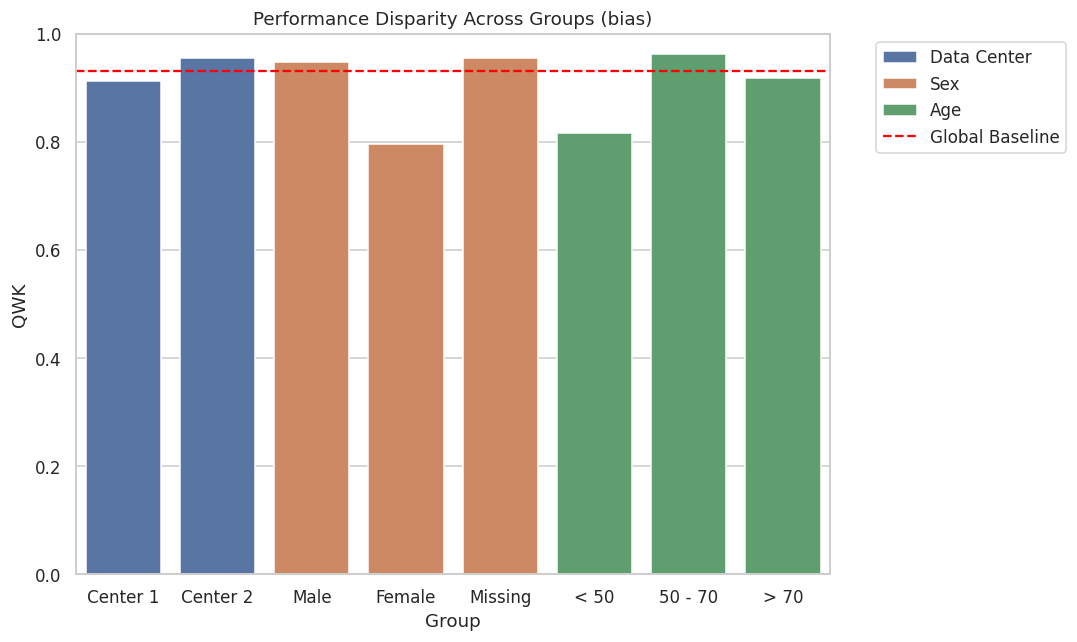


--- Accuracy Bias Audit: bias ---


,Category,Group,N,Accuracy
0,Data Center,Center 1,154,0.8766
1,Data Center,Center 2,18,0.7778
2,Sex,Male,108,0.9074
3,Sex,Female,46,0.8043
4,Sex,Missing,18,0.7778
5,Age,< 50,62,0.8065
6,Age,50 - 70,95,0.9158
7,Age,> 70,15,0.8000


<Figure size 704x528 with 0 Axes>

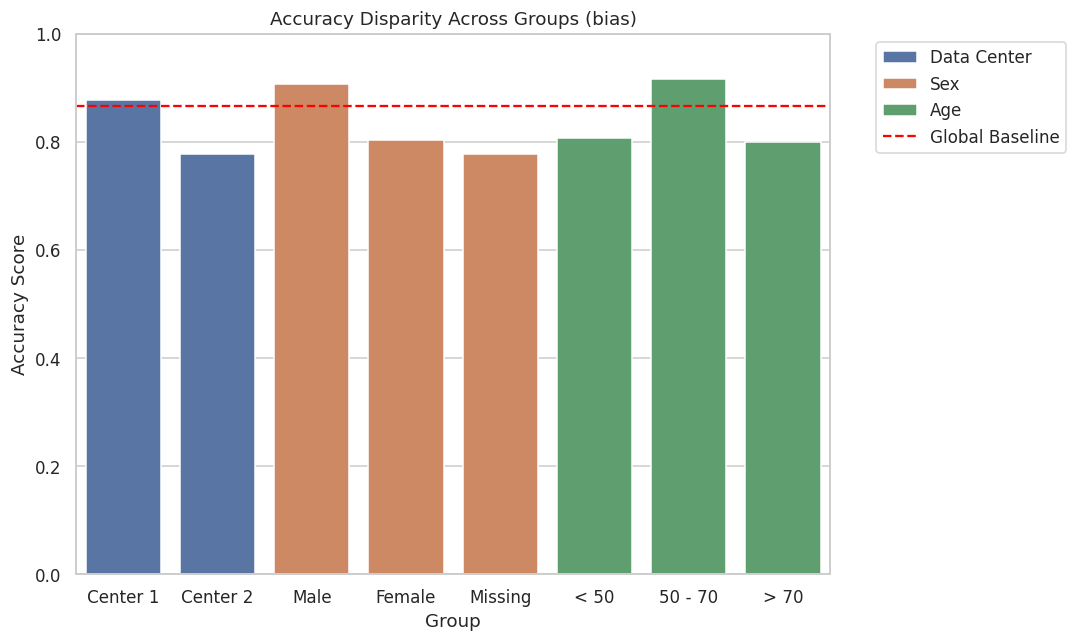

Main baseline test-set bootstrap CIs (bias_fairness_loss_lamba_0.5_total):


,metric,point,ci_low,ci_high,std
0,accuracy,0.7016,0.6452,0.7581,0.0285
1,balanced_accuracy,0.6282,0.5418,0.7120,0.0436
2,macro_f1,0.6475,0.5493,0.7310,0.0455
3,weighted_f1,0.6980,0.6387,0.7551,0.0293
4,quadratic_kappa,0.7962,0.7312,0.8561,0.0326
5,macro_auroc,0.8899,0.8496,0.9228,0.0188



--- Bias Audit: bias_fairness_loss_lamba_0.5_total ---


,Category,Group,N,QWK
0,Data Center,Center 1,154,0.8457
1,Data Center,Center 2,18,0.9333
2,Sex,Male,108,0.8609
3,Sex,Female,46,0.7980
4,Sex,Missing,18,0.9333
5,Age,< 50,62,0.8560
6,Age,50 - 70,95,0.8400
7,Age,> 70,15,0.9675


<Figure size 704x528 with 0 Axes>

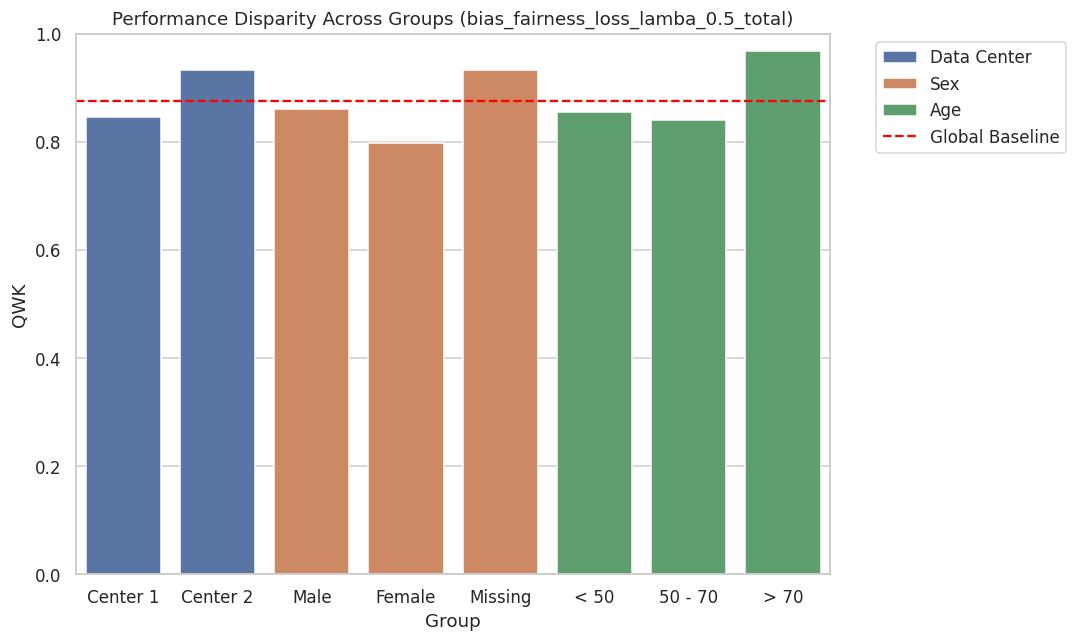


--- Accuracy Bias Audit: bias_fairness_loss_lamba_0.5_total ---


,Category,Group,N,Accuracy
0,Data Center,Center 1,154,0.7857
1,Data Center,Center 2,18,0.7222
2,Sex,Male,108,0.7963
3,Sex,Female,46,0.7609
4,Sex,Missing,18,0.7222
5,Age,< 50,62,0.7903
6,Age,50 - 70,95,0.7474
7,Age,> 70,15,0.9333


<Figure size 704x528 with 0 Axes>

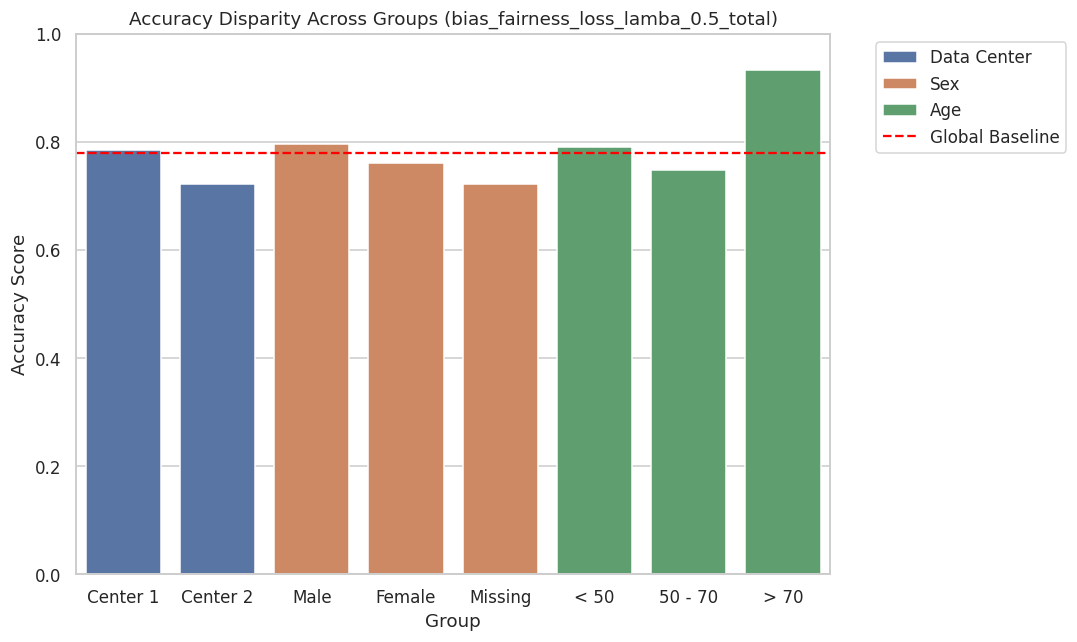

Main baseline test-set bootstrap CIs (bias_fairness_loss_balanced_sampler_lamba_0.5_total):


,metric,point,ci_low,ci_high,std
0,accuracy,0.6694,0.6169,0.7258,0.0283
1,balanced_accuracy,0.5854,0.5015,0.6726,0.0431
2,macro_f1,0.5972,0.5056,0.6837,0.0453
3,weighted_f1,0.6591,0.6005,0.7162,0.0303
4,quadratic_kappa,0.7495,0.6761,0.8202,0.0375
5,macro_auroc,0.8908,0.8484,0.9251,0.0206



--- Bias Audit: bias_fairness_loss_balanced_sampler_lamba_0.5_total ---


,Category,Group,N,QWK
0,Data Center,Center 1,154,0.9055
1,Data Center,Center 2,18,0.9071
2,Sex,Male,108,0.9058
3,Sex,Female,46,0.9042
4,Sex,Missing,18,0.9071
5,Age,< 50,62,0.8852
6,Age,50 - 70,95,0.9059
7,Age,> 70,15,0.9414


<Figure size 704x528 with 0 Axes>

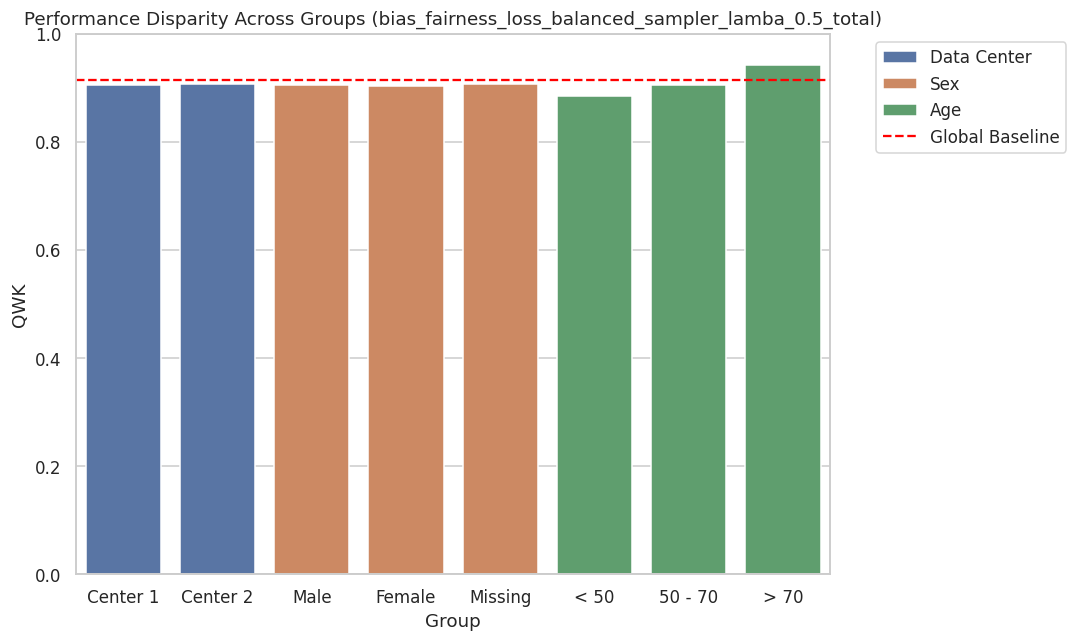


--- Accuracy Bias Audit: bias_fairness_loss_balanced_sampler_lamba_0.5_total ---


,Category,Group,N,Accuracy
0,Data Center,Center 1,154,0.8442
1,Data Center,Center 2,18,0.7222
2,Sex,Male,108,0.8333
3,Sex,Female,46,0.8696
4,Sex,Missing,18,0.7222
5,Age,< 50,62,0.8387
6,Age,50 - 70,95,0.8211
7,Age,> 70,15,0.8667


<Figure size 704x528 with 0 Axes>

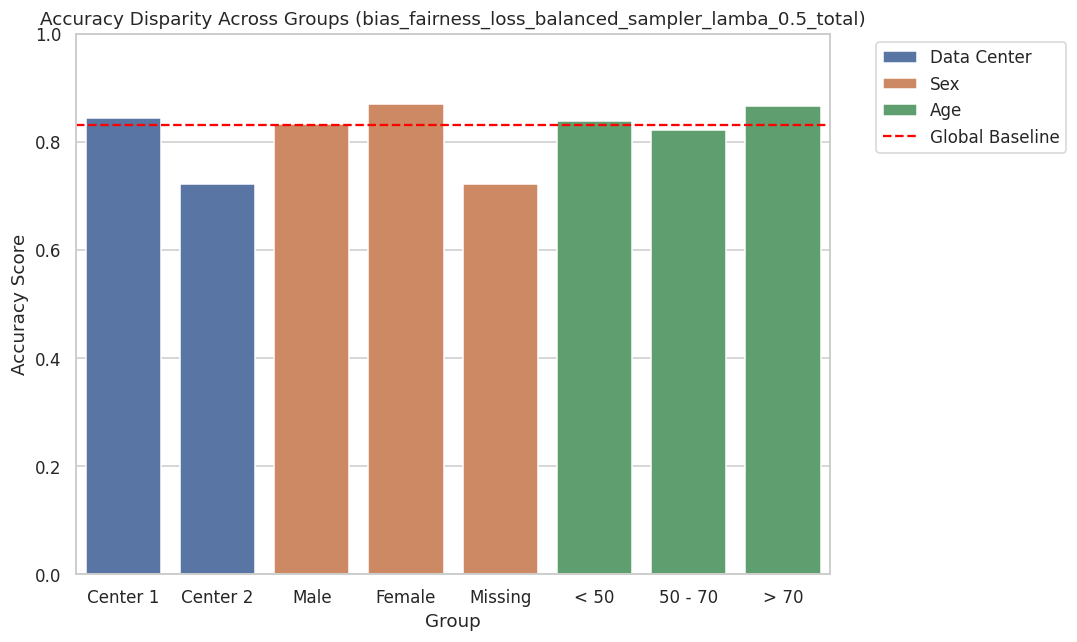

<Figure size 704x528 with 0 Axes>

In [35]:
if RESULTS_AVAILABLE:
    for name in experiment_outputs:
        base = experiment_outputs[name]
        base_cfg = base['config']
        base_result = base['result']
        val_bundle  = base['val_bundle']
        test_bundle = base['test_bundle']

        test_preds = np.load(base_cfg.output_dir / f'{name}_test_predictions.npz')
        test_y_main  = test_preds['y_true']
        test_yp_main = test_preds['y_pred']
        test_prob_main = test_preds['y_prob']
        ci = bootstrap_metrics(
            test_y_main, test_yp_main, test_prob_main,
            n_resamples=1000, ci_level=0.95, seed=main_config.seed,
        )
        print(f'Main baseline test-set bootstrap CIs ({name}):')

        ci_df = pd.DataFrame([
            {'metric': m, 'point': round(e['point'], 4),
            'ci_low': round(e['ci_low'], 4), 'ci_high': round(e['ci_high'], 4),
            'std': round(e['std'], 4)}
            for m, e in ci.items()
        ])
        ci_df.to_csv(base_cfg.output_dir / f'{name}_test_bootstrap_ci.csv', index=False)
        display(ci_df)

        bias_df = analyze_bias(base_cfg.output_dir / f'{name}_val_predictions.npz', name, save_path=base_cfg.output_dir / f'{name}_qwk_val.png')
        bias_df_acc = analyze_accuracy_bias(base_cfg.output_dir / f'{name}_val_predictions.npz', name,save_path=base_cfg.output_dir / f'{name}_acc_val.png')

else:
    print('Skipped: no baseline results available.')

Investigate age bias

In [ ]:
if RESULTS_AVAILABLE:
    for name in experiment_outputs:
        data = np.load(base_cfg.output_dir / f'{name}_test_predictions.npz')
        mask_young = (data['age'] > 0) & (data['age'] < 50)
        print('Model: ', name)
        print("Confusion Matrix for Patients < 50:")
        print(confusion_matrix(data['y_true'][mask_young], data['y_pred'][mask_young]))
        print()

In [ ]:
for name, out  in experiment_outputs.items():
    base = experiment_outputs[name]
    base_cfg = base['config']
    base_result = base['result']
    val_bundle  = base['val_bundle']
    test_bundle = base['test_bundle']

    print(f'Experiment: {name}')
    print(f'  best epoch    : {base_result.best_epoch + 1}')
    print(f'  best val {base_result.primary_metric}: {base_result.best_metric:.4f}')
    print()
    print(f'VAL  : {val_bundle.pretty()}')
    print(f'TEST : {test_bundle.pretty()}')


    val_preds = np.load(base_cfg.output_dir / f'{name}_val_predictions.npz')
    val_y_main  = val_preds['y_true']
    val_yp_main = val_preds['y_pred']
    val_prob_main = val_preds['y_prob']

    per_class_val = pd.DataFrame({
        'class'    : list(CLASS_NAMES),
        'support'  : val_bundle.per_class_support,
        'precision': val_bundle.per_class_precision,
        'recall'   : val_bundle.per_class_recall,
        'f1'       : val_bundle.per_class_f1,
    }).round(4)
    per_class_val.to_csv(base_cfg.output_dir / f'{name}_val_per_class.csv', index=False)
    display(per_class_val)

    test_preds = np.load(base_cfg.output_dir / f'{name}_test_predictions.npz')
    test_y_main  = test_preds['y_true']
    test_yp_main = test_preds['y_pred']
    test_prob_main = test_preds['y_prob']

    per_class_test = pd.DataFrame({
        'class'    : list(CLASS_NAMES),
        'support'  : test_bundle.per_class_support,
        'precision': test_bundle.per_class_precision,
        'recall'   : test_bundle.per_class_recall,
        'f1'       : test_bundle.per_class_f1,
    }).round(4)
    per_class_test.to_csv(base_cfg.output_dir / f'{name}_test_per_class.csv', index=False)
    display(per_class_test)


## 13. Visualisation


In [ ]:
BEST_MODEL_NAME= f'{BASELINE_NAME}_imbalances_strategies_combined'
# Training / validation curves
fig = plot_training_curves(
    base_result.history,
    save_path=base_cfg.output_dir / BEST_MODEL_NAME,
)
plt.show()


In [ ]:
if RESULTS_AVAILABLE:
    short_names = [f'Grade {i}' for i in range(NUM_CLASSES)]

    fig_val = plot_confusion_matrix(
        np.array(val_bundle.confusion_matrix), short_names,
        title='Validation confusion matrix',
        save_path=base_cfg.output_dir / f'{BEST_MODEL_NAME}_cm_val.png',
    )
    plt.show()
    fig_test = plot_confusion_matrix(
        np.array(test_bundle.confusion_matrix), short_names,
        title='Test confusion matrix',
        save_path=base_cfg.output_dir / f'{BEST_MODEL_NAME}_cm_test.png',
    )
    plt.show()
else:
    print('Skipped: no evaluation results available.')


## 14. Ablation analysis


In [ ]:
def load_experiment_artefacts(exp_name: str) -> Optional[Dict[str, Any]]:
    """Load summary + history + test/val predictions for one experiment.

    Returns None if the artefacts are missing (e.g. the user ran with
    TRAIN=False and that experiment wasn't previously trained).
    """
    out_dir = OUTPUT_DIR / 'baseline'
    paths = {
        'summary'   : out_dir / f'{exp_name}_summary.json',
        'history'   : out_dir / f'{exp_name}_history.json',
        'test_preds': out_dir / f'{exp_name}_test_predictions.npz',
        'val_preds' : out_dir / f'{exp_name}_val_predictions.npz',
    }
    if not all(p.is_file() for p in paths.values()):
        return None
    summary = json.loads(paths['summary'].read_text())
    history = json.loads(paths['history'].read_text())
    test    = np.load(paths['test_preds'])
    val     = np.load(paths['val_preds'])
    return {
        'name'     : exp_name,
        'summary'  : summary,
        'history'  : history,
        'test_y'   : test['y_true'], 'test_yp'  : test['y_pred'], 'test_prob': test['y_prob'],
        'val_y'    : val['y_true'],  'val_yp'   : val['y_pred'],  'val_prob' : val['y_prob'],
    }

PRETTY = {
    BASELINE_NAME        : 'Baseline (224, aug on, 100 %)',
    f'{BASELINE_NAME}_img384' : 'Image size 384',
    f'{BASELINE_NAME}_max_pooling': 'Max Pooling + Avrg Pooling',
    f'{BASELINE_NAME}_weightedce_smoothing': 'Weighted Cross Entropy, Label Smoothing=0.1',
    f'{BASELINE_NAME}_imbalances_strategies_combined': 'All imbalances strategies combined',

    f'{BASELINE_NAME}_noaug'  : 'No augmentation',
    f'{BASELINE_NAME}_frac30' : 'Train 30 %',
    f'{BASELINE_NAME}_frac60' : 'Train 60 %',

}
runs = {name: art for name in EXPERIMENTS if (art := load_experiment_artefacts(name)) is not None}
print(f'Loaded {len(runs)} / {len(EXPERIMENTS)} experiments for ablation analysis:')
for name in runs:
    print(f'  {name}')
missing = [n for n in EXPERIMENTS if n not in runs]
if missing:
    print(f'Missing (skipped gracefully): {missing}')


In [ ]:
def compare_to_baseline(target_name: str, metric: str = 'quadratic_kappa'):
    if target_name not in runs or BASELINE_NAME not in runs:
        return None
    a = runs[target_name]
    b = runs[BASELINE_NAME]
    return paired_bootstrap_compare(
        a['test_y'], a['test_yp'], b['test_yp'],
        a['test_prob'], b['test_prob'],
        metric=metric, n_resamples=2000, seed=main_config.seed,
    )

def summarise_comparison(name: str, cmp: Optional[Dict[str, float]]):
    if cmp is None:
        return None
    return {
        'experiment'         : PRETTY[name] if name in PRETTY else name,
        'kappa'              : round(cmp['metric_a'], 4),
        'kappa_baseline'     : round(cmp['metric_b'], 4),
        'delta'              : round(cmp['delta'], 4),
        'ci_low'             : round(cmp['ci_low'], 4),
        'ci_high'            : round(cmp['ci_high'], 4),
        'p_value'            : round(cmp['p_value'], 4),
        'significant_at_5pct': cmp['p_value'] < 0.05,
    }


### Combined ablation table


In [ ]:
rows = []
for name in EXPERIMENTS:
    if name not in runs:
        continue
    r = summarise_comparison(name, compare_to_baseline(name))
    if r is not None:
        rows.append(r)

if BASELINE_NAME in runs:
    base_ci = bootstrap_metrics(
        runs[BASELINE_NAME]['test_y'],
        runs[BASELINE_NAME]['test_yp'],
        runs[BASELINE_NAME]['test_prob'],
        n_resamples=1000, seed=main_config.seed,
    )
    rows.insert(0, {
        'experiment'         : PRETTY[BASELINE_NAME],
        'kappa'              : round(base_ci['quadratic_kappa']['point'], 4),
        'kappa_baseline'     : round(base_ci['quadratic_kappa']['point'], 4),
        'delta'              : 0.0,
        'ci_low'             : None,
        'ci_high'            : None,
        'p_value'            : None,
        'significant_at_5pct': None,
    })

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(OUTPUT_DIR / 'baseline' / 'ablation_summary_table.csv', index=False)
ablation_df
